# Description
Trying to improve the calculation of the number of pases by changeing th egrid generation from rectangles to lines.

In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate, translate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


# Configuration

In [3]:
tol_deg  = 5.5
street_length = 7
sampling_distance = 10
dx = 0.5         # Thickness of each vertical bar
angles = np.arange(0, 190, 10)

# Query the surveys

In [4]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [5]:
# Compute the union of the survey geometries and simplify the result
survey_union = survey_gdf.unary_union.simplify(2)  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [6]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

survey_boundary_gdf = gpd.GeoDataFrame({'geometry': [survey_union_offset_gdf.geometry.boundary.values[0]]}, crs=survey_gdf.crs)

Center of the bounds: POINT (705580.31269 5716709.058445)


In [7]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

<Axes: >

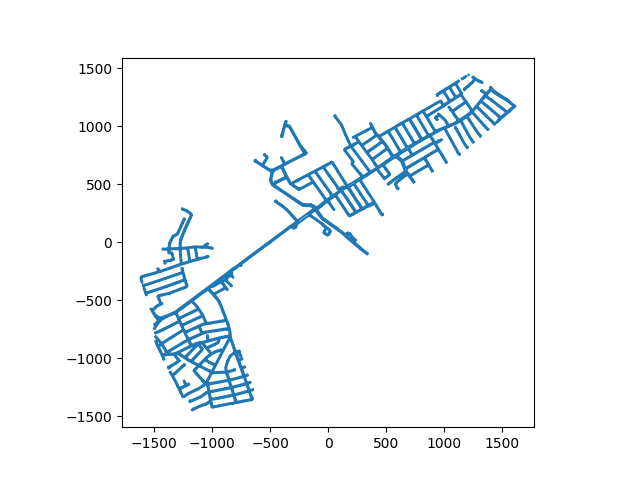

In [8]:
survey_union_offset_gdf.set_geometry('geometry', inplace=True)
survey_boundary_gdf.plot()


# Generate the grid

## Rotate the grid

In [9]:
from geopandas import sjoin_nearest

output_gdf = gpd.GeoDataFrame()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, angle in enumerate(angles):
        print(f'Processing angle: {angle}')
        # Parameters for evenly spaced thin vertical rectangles (grid "bars")
        bounds = survey_union_offset_gdf.total_bounds
        min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
        r_x = np.sqrt(max_x**2 + max_y**2)
        r_y = np.sqrt(min_x**2 + min_y**2)

        # Compute number of columns safely and cast to int
        num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

        # Compute bar center x-positions
        x_centers = np.linspace(-r_x, r_x, num=num_cols)

        # For each center, form a thin rectangle as a LineString (vertical line between min_y and max_y)
        vertical_bars = [
            LineString([
                (x, min_y),
                (x, max_y)
            ])
            for x in x_centers
        ]


        #-- Grid aligned with the base vectors [1.0], 
        grid_lines_gdf = gpd.GeoDataFrame({'geometry': vertical_bars}, crs='EPSG:3857', geometry='geometry')
        grid_lines_gdf['grid_idx'] = grid_lines_gdf.index

        # Add a column to grid_lines_gdf where each geometry is translated by dx to the right
        grid_lines_gdf['gemetry_dx'] = grid_lines_gdf['geometry'].translate(dx, 0)

        # Define the vector
        vec = np.array([1,0]) 
        ortho_vec = np.array([0,1])
        # Define a rotation angle in radians (example: 45 degrees)
        theta = np.deg2rad(angle)
        rotation_matrix = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]
        ])

        # Rotate the vector by the rotation matrix
        rotated_vec = rotation_matrix @ vec
        rotated_ortho_vec = rotation_matrix @ ortho_vec

        # Rotate the grid lines accordingly
        vertical_bars_r = [rotate(bar, angle=angle, origin=(0,0)) for bar in vertical_bars]
        # Shapely's LineString does not have a .translate method; use shapely.affinity.translate instead
        vertical_bars_r_dx = [rotate(translate(bar, xoff=dx, yoff=0), angle=angle, origin=(0,0)) for bar in vertical_bars]
        grid_lines_gdf_r = gpd.GeoDataFrame({'geometry': vertical_bars_r}, crs='EPSG:3857', geometry='geometry')
        grid_lines_gdf_r_dx = gpd.GeoDataFrame({'geometry': vertical_bars_r_dx}, crs='EPSG:3857', geometry='geometry')
        grid_lines_gdf_r['grid_idx'] = grid_lines_gdf_r.index
        grid_lines_gdf_r_dx['grid_idx'] = grid_lines_gdf_r_dx.index

        #Create the intersection of the grid with the survey offset edges
        intersection_x_gdf = gpd.overlay(
            grid_lines_gdf_r, 
            survey_boundary_gdf, 
            how='intersection', 
            keep_geom_type=False
        )
        intersection_dx_gdf = gpd.overlay(
            grid_lines_gdf_r_dx, 
            survey_boundary_gdf, 
            how='intersection', 
            keep_geom_type=False
        )

        #Expand all the multipoints into single points
        intersection_x_gdf.set_geometry('geometry', inplace=True)
        intersection_x_gdf.set_crs('EPSG:3857', inplace=True)
        intersection_x_gdf = intersection_x_gdf.explode(ignore_index=True)
        
        intersection_dx_gdf.set_geometry('geometry', inplace=True)
        intersection_dx_gdf.set_crs('EPSG:3857', inplace=True)
        intersection_dx_gdf = intersection_dx_gdf.explode(ignore_index=True)

        #Restore indexes
        intersection_x_gdf = intersection_x_gdf.reset_index(drop=True)
        intersection_dx_gdf = intersection_dx_gdf.reset_index(drop=True)

        #Rotate the points to the original Frame of reference
        intersection_x_gdf['geometry_F0'] = intersection_x_gdf['geometry'].apply(
            lambda geom: rotate(geom, angle=-angle, origin=(0, 0))
        )
        #Sort the points by the y-coordinate
        intersection_x_gdf['geometry_F0_y'] = intersection_x_gdf['geometry_F0'].apply(lambda geom: geom.y)
        intersection_x_gdf.sort_values(by='geometry_F0_y', inplace=True)

        #In the F0 frame of reference, assign the index of the previous (higher-y) row as 'top_point_idx'
        intersection_x_gdf = assign_top_point(intersection_x_gdf)
        # In the F0 frame of reference, assign the geometry corresponding to its top_point_idx
        intersection_x_gdf = assign_top_geometry(intersection_x_gdf)    

        #In the rotated frame of reference, add a displacement dy to the points
        intersection_x_gdf['dy'] = intersection_x_gdf['geometry'].apply(lambda geom: vector_to_point(geom.centroid, rotated_ortho_vec, length=dx))

        # Assign x to dx: nearest only *within the same grid_idx*. A global sjoin_nearest
        # can match a point on line i to the dx offset of line j when lines are close (angle-dependent),
        # which corrupts unit_vector / filtering.
        result = sjoin_nearest(
            intersection_x_gdf,
            intersection_dx_gdf,
            max_distance=dx * 2,
            distance_col="distance",
        )
        result["index_right"] = result["index_right"].astype("Int64")  # Nullable integer to handle nans if present
        # Must pass the DataFrame and column name to safe_get_geometry via lambda
        result['dx'] = result['index_right'].apply(lambda ix: safe_get_geometry(ix, intersection_dx_gdf, geometry_col='geometry'))

        #Assign lines, this step can be ommited. It is to visualize the lines along the orthogonal axes to the trajectory
        #result['line_x'] = result.apply(lambda row: line_between_points(row,row['geometry'],row['dx']), axis=1)
        #result['line_y'] = result.apply(lambda row: line_between_points(row,row['geometry'],row['top_geometry']), axis=1)

        #Get the unit vector of the line x
        result['unit_vector'] = result.apply(lambda row: unit_vector_between_points(row['geometry'], row['dx']), axis=1)
        # Get teh angle between the unit vector and the rotated vector
        result['angle'] = result['unit_vector'].apply(lambda vec: angle_between_vectors(vec, rotated_vec=rotated_vec))
        # Get only those lines which are aligned with the rotated vector
        right_angles = result[np.isclose(result['angle'], 0, atol=tol_deg)]

        # Select those right_angles whose 'dx' point is inside the survey_boundary
        filtered_right_angles = right_angles[right_angles['dy'].within(survey_union_offset_gdf.unary_union)]

        if len(filtered_right_angles) > 0:
            #print('There is a right angle')
            #Get the cell boundaries
            filtered_right_angles['cell_boundary'] = filtered_right_angles.apply(lambda row: get_line_from_angle(row, rotated_ortho_vec), axis=1)

            #Rename the grid_idx to include the angle
            filtered_right_angles.reset_index(drop=True)
            output_gdf = pd.concat([output_gdf, filtered_right_angles])
        else:
            print(f'No right angles found for angle {angle}')

Processing angle: 0
Processing angle: 10
Processing angle: 20
Processing angle: 30
Processing angle: 40
Processing angle: 50
Processing angle: 60
Processing angle: 70
Processing angle: 80
Processing angle: 90
Processing angle: 100
Processing angle: 110
Processing angle: 120
Processing angle: 130
Processing angle: 140
Processing angle: 150
Processing angle: 160
Processing angle: 170
Processing angle: 180


In [10]:
# Remove entries whose cell_boundary length > 1 std above the mean
lengths = output_gdf.cell_boundary.length
mean_length = lengths.mean()
std_length = lengths.std()
filtered_output_gdf = output_gdf[lengths <= (mean_length + std_length)]


#Remove all the intersecting 
#Create the cells
geom = survey_union_offset_gdf.iloc[0].geometry

# All grid lines as one noded multiline (tweak attribute if your geometry column differs)
lines = [getattr(row, "cell_boundary") for row in filtered_output_gdf.itertuples()]
splitters = unary_union(lines)
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]
print(len(lines), "splitters ->", len(cell_polys), "cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.reset_index().rename(columns={'index': 'cell_idx'})
    

3378 splitters -> 2456 cells


In [11]:
# Ensure the cell_offset_gdf is a GeoDataFrame, not a GeoSeries
cell_offset_gdf = gpd.GeoDataFrame(geometry=cell_gdf.buffer(-0.05), crs=cell_gdf.crs)

In [12]:
# Instead of using overlay (which only works for GeoDataFrames), do direct intersection between survey_gdf and cell_offset_gdf boundaries

# Get the boundaries as a GeoDataFrame
cell_boundaries_gdf = gpd.GeoDataFrame(geometry=cell_offset_gdf.boundary, crs=cell_offset_gdf.crs)

points = gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode()
# Segment the survey_gdf into its individual line segments

/tmp/ipykernel_482/986452470.py:6: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  points = gpd.overlay(survey_gdf, cell_boundaries_gdf, how='intersection', keep_geom_type=False).explode()


In [13]:
# Split the cell boundaries into individual line segments
cell_boundary_segments = cell_boundaries_gdf.geometry.apply(
    lambda geom: [LineString([geom.coords[i], geom.coords[i+1]]) for i in range(len(geom.coords)-1)]
    if geom.geom_type == 'LineString' else []
)
cell_boundary_segments = [seg for seglist in cell_boundary_segments for seg in seglist]  # flatten
cell_boundary_segments_gdf = gpd.GeoDataFrame(geometry=cell_boundary_segments, crs=cell_boundaries_gdf.crs)
cell_boundary_segments_gdf

,geometry
0,"LINESTRING (-299.219 213.240, -305.783 220.679)"
1,"LINESTRING (-305.783 220.679, -298.390 226.882)"
2,"LINESTRING (-298.390 226.882, -291.694 219.554)"
3,"LINESTRING (-291.694 219.554, -299.219 213.240)"
4,"LINESTRING (-305.849 220.754, -312.414 228.193)"
...,...
36736,"LINESTRING (-1432.553 -528.632, -1430.659 -527..."
36737,"LINESTRING (-1430.659 -527.042, -1431.036 -529..."
36738,"LINESTRING (-919.382 -340.079, -919.580 -340.114)"
36739,"LINESTRING (-919.580 -340.114, -919.010 -339.435)"


<Axes: >

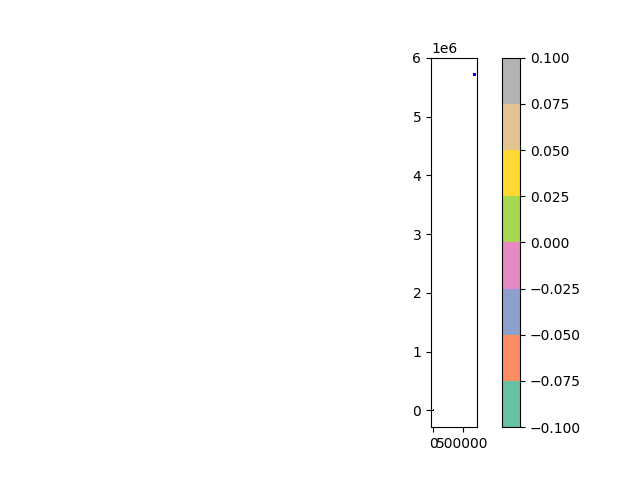

In [14]:
# Merge cell_gdf with the grouped join result on cell_idx and index_right
joined_gdf = gpd.sjoin(points, cell_gdf, how='left', predicate='intersects')
# Get intersection counts by cell
cell_counts = joined_gdf.groupby('index_right').size().reset_index(name='count')

# Merge with cell_gdf to add count to each cell using left join
cell_gdf_with_count = cell_gdf.merge(cell_counts, left_on='cell_idx', right_on='index_right', how='left')
cell_gdf_with_count['passes'] = cell_gdf_with_count['count'] /2
# Plot the grids and survey_gdf on the same axes so both show up
ax = cell_gdf_with_count.plot(column='passes', cmap='Set2', legend=True)
survey_gdf.plot(ax=ax, color='blue', alpha=0.2)
cell_gdf.boundary.plot(ax=ax, edgecolor='black', alpha=0.2, linewidth=0.5)